# Fase 2 — Modelagem e avaliação

Nesta etapa, usamos a base preparada na Fase 1 para testar uma
correção da pesquisa de 1936. Treinamos uma regressão linear com
a pesquisa da Literary Digest de 1932 e os resultados reais
daquela eleição. Depois, aplicamos essa relação à pesquisa de 1936.

Trabalhamos com dados de 48 estados. Cada linha representa um
estado, e as proporções consideram apenas os dois principais
candidatos de cada eleição.

**Como executar no Google Colab**

Execute as células na ordem apresentada. No primeiro pedido de
upload, envie `analysis_1936.csv`, produzido na Fase 1. No segundo,
envie `LitDigestFull.xlsx`, fornecido pela disciplina.

Ao final, o notebook gera quatro tabelas CSV e dois gráficos PNG,
reunidos no arquivo `fase2_resultados.zip`.

## 1. Carregamento da base preparada na Fase 1

In [2]:
import pandas as pd
from google.colab import files

# Enviar a base preparada na Fase 1
arquivos_enviados = files.upload()

Saving analysis_1936.csv to analysis_1936.csv


In [3]:
df_1936 = pd.read_csv("analysis_1936.csv")

print(f"Estados: {df_1936.shape[0]}")
print(f"Colunas: {df_1936.shape[1]}")

df_1936.head()

Estados: 48
Colunas: 59


,state,electoral_vote,landon,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_others,landon_1932_did_not_vote,landon_1932_vote_not_indicated,roosevelt,...,state_abbr,landon_share_total,roosevelt_share_total,landon_share_two_party,roosevelt_share_two_party,actual_landon_share,actual_roosevelt_share,landon_error,roosevelt_error,absolute_landon_error
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,...,AL,0.230543,0.759587,0.232841,0.767159,0.129283,0.870717,0.103559,-0.103559,0.103559
1,Arizona,3,2337,1431,647,18,0,129,112,1975,...,AZ,0.522118,0.441242,0.541976,0.458024,0.278249,0.721751,0.263727,-0.263727,0.263727
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,...,AR,0.258444,0.721822,0.263647,0.736353,0.179185,0.820815,0.084462,-0.084462,0.084462
3,California,22,89516,65360,16200,315,53,3519,4069,77245,...,CA,0.514652,0.444103,0.536792,0.463208,0.321301,0.678699,0.215492,-0.215492,0.215492
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,...,CO,0.595423,0.374263,0.614037,0.385963,0.380583,0.619417,0.233454,-0.233454,0.233454


## 2. Preparação dos resultados eleitorais de 1932

Extraímos os votos de Roosevelt e Hoover registrados na planilha.
A participação republicana será calculada considerando somente esses
dois candidatos, mantendo o mesmo critério utilizado na análise de 1936.

In [4]:
# Enviar o arquivo LitDigestFull.xlsx
arquivos_1932 = files.upload()

Saving LitDigestFull.xlsx to LitDigestFull.xlsx


In [5]:
# O bloco de resultados eleitorais começa na coluna AB.
# As primeiras 48 linhas de dados correspondem aos estados.
df_1932 = pd.read_excel(
    "LitDigestFull.xlsx",
    sheet_name="1932",
    usecols="AB,AD,AG",
    nrows=48,
)

df_1932 = df_1932.rename(columns={
    "State - 1932": "state",
    "Roosevelt": "roosevelt_votes_1932",
    "Hoover": "hoover_votes_1932",
})

df_1932["state"] = df_1932["state"].str.strip()

df_1932.head()

,state,roosevelt_votes_1932,hoover_votes_1932
0,Alabama,207910,34675
1,Arizona,79264,36104
2,Arkansas,189602,28467
3,California,1324157,847902
4,Colorado,250877,189617


In [6]:
colunas_votos = [
    "roosevelt_votes_1932",
    "hoover_votes_1932",
]

assert df_1932["state"].is_unique, "Há estados repetidos."
assert set(df_1932["state"]) == set(df_1936["state"]), (
    "Os estados de 1932 e 1936 não correspondem."
)
assert not df_1932[colunas_votos].isna().any().any(), (
    "Há valores ausentes nos votos."
)
assert (df_1932[colunas_votos] >= 0).all().all(), (
    "Há valores negativos nos votos."
)

total_dois_partidos_1932 = df_1932[colunas_votos].sum(axis=1)

assert (total_dois_partidos_1932 > 0).all(), (
    "Há estado sem votos nos dois partidos."
)

df_1932["actual_rep_share_1932"] = (
    df_1932["hoover_votes_1932"] / total_dois_partidos_1932
)

print(f"Estados de 1932: {len(df_1932)}")
print("Correspondência com 1936: OK")

df_1932.head()

Estados de 1932: 48
Correspondência com 1936: OK


,state,roosevelt_votes_1932,hoover_votes_1932,actual_rep_share_1932
0,Alabama,207910,34675,0.142940
1,Arizona,79264,36104,0.312946
2,Arkansas,189602,28467,0.130541
3,California,1324157,847902,0.390368
4,Colorado,250877,189617,0.430464


## 3. Junção dos dados de 1932 e 1936

Combinamos as bases pelo nome do estado. A junção deve preservar os
48 estados e associar cada um a um único registro de 1932.

Os resultados reais de 1936 serão utilizados na avaliação da correção.

In [7]:
df_modelagem = df_1936.merge(
    df_1932,
    on="state",
    how="left",
    validate="one_to_one",
    indicator=True,
)

assert (df_modelagem["_merge"] == "both").all(), (
    "Há estados sem correspondência em 1932."
)

df_modelagem = df_modelagem.drop(columns="_merge")

assert len(df_modelagem) == 48, "A base deve conter 48 estados."

print(f"Estados: {df_modelagem.shape[0]}")
print(f"Colunas: {df_modelagem.shape[1]}")

df_modelagem[[
    "state",
    "landon_share_two_party",
    "actual_rep_share_1932",
    "actual_landon_share",
]].head()

Estados: 48
Colunas: 62


,state,landon_share_two_party,actual_rep_share_1932,actual_landon_share
0,Alabama,0.232841,0.142940,0.129283
1,Arizona,0.541976,0.312946,0.278249
2,Arkansas,0.263647,0.130541,0.179185
3,California,0.536792,0.390368,0.321301
4,Colorado,0.614037,0.430464,0.380583


## 4. Erro da pesquisa original

Calculamos o MAE e o RMSE da participação de Landon na pesquisa,
comparando-a com o resultado eleitoral de 1936.

As duas proporções consideram somente Landon e Roosevelt.
Os erros são apresentados em pontos percentuais, com peso igual
para cada estado.

In [8]:
erro_original_pp = 100 * (
    df_modelagem["landon_share_two_party"]
    - df_modelagem["actual_landon_share"]
)

mae_original = erro_original_pp.abs().mean()
rmse_original = (erro_original_pp.pow(2).mean()) ** 0.5


print(f"MAE original: {mae_original:.2f} p.p.")
print(f"RMSE original: {rmse_original:.2f} p.p.")

MAE original: 18.62 p.p.
RMSE original: 20.06 p.p.


## 5. Preparação dos dados de treinamento

Utilizamos a pesquisa da Literary Digest de 1932 e os resultados reais daquela eleição para preparar os dados do treinamento. Calculamos a participação republicana considerando somente Hoover e Roosevelt.

Mantivemos os mesmos 48 estados da análise de 1936. Os registros do Distrito de Columbia, de estado desconhecido e do total geral foram separados para conferência e não participaram do treinamento.

Antes de juntar os dados, conferimos se existem estados repetidos, valores ausentes ou contagens inválidas.


In [9]:
df_poll_1932 = pd.read_excel(
    "LitDigestFull.xlsx",
    sheet_name="1932",
    header=None,
    skiprows=2,
    usecols="A,C,J",
    names=["state", "poll_hoover_1932", "poll_roosevelt_1932"],
)

df_poll_1932["state"] = (
    df_poll_1932["state"].str.strip().str.title()
)

# Separar os registros que não pertencem aos 48 estados da análise
estados_da_analise = df_poll_1932["state"].isin(df_1932["state"])

linhas_separadas_1932 = df_poll_1932.loc[
    ~estados_da_analise
].copy()

df_poll_1932 = df_poll_1932.loc[estados_da_analise].copy()

print("Registros separados da análise:")
print(linhas_separadas_1932.to_string(index=False))

# Conferir os dados antes de calcular as proporções.
colunas_poll = ["poll_hoover_1932", "poll_roosevelt_1932"]

assert len(df_poll_1932) == 48, "A pesquisa deve conter 48 estados."
assert df_poll_1932["state"].is_unique, "Há estados repetidos."

assert set(df_poll_1932["state"]) == set(df_1932["state"]), (
    "Os estados da pesquisa e do resultado real de 1932 não correspondem."
)

assert not df_poll_1932[colunas_poll].isna().any().any(), (
    "Há valores ausentes na pesquisa."
)

assert (df_poll_1932[colunas_poll] >= 0).all().all(), (
    "Há valores negativos na pesquisa."
)

total_poll_1932 = df_poll_1932[colunas_poll].sum(axis=1)

assert (total_poll_1932 > 0).all(), (
    "Há estado com total inválido na pesquisa."
)

# Hoover era o candidato republicano em 1932
df_poll_1932["poll_rep_share_1932"] = (
    df_poll_1932["poll_hoover_1932"] / total_poll_1932
)

# Juntar a proporção da pesquisa com a proporção do resultado real
base_treino_1932 = df_1932[
    ["state", "actual_rep_share_1932"]
].merge(
    df_poll_1932[["state", "poll_rep_share_1932"]],
    on="state",
    how="left",
    validate="one_to_one",
)

assert len(base_treino_1932) == 48, (
    "A base de treinamento deve conter 48 estados."
)

assert not base_treino_1932.isna().any().any(), (
    "Há estado sem dados para o treinamento."
)

print(f"\nEstados na base de treinamento: {len(base_treino_1932)}")

base_treino_1932.head()

Registros separados da análise:
               state  poll_hoover_1932  poll_roosevelt_1932
District Of Columbia              3937                 5061
       State Unknown             17661                30749
             Totals:           1150398              1715789

Estados na base de treinamento: 48


,state,actual_rep_share_1932,poll_rep_share_1932
0,Alabama,0.142940,0.174845
1,Arizona,0.312946,0.343934
2,Arkansas,0.130541,0.186186
3,California,0.390368,0.354773
4,Colorado,0.430464,0.455169


## 6. Regressão linear e previsão corrigida

A variável de entrada é a participação republicana na pesquisa de 1932.
A variável que o modelo aprende a estimar é a participação republicana
no resultado real de 1932.

Aplicamos a relação aprendida à participação de Landon na pesquisa
de 1936. Os resultados reais de 1936 ficam reservados para avaliação.

A hipótese é que a relação observada em 1932 seja aplicável a 1936.
Mudanças no viés entre eleições podem limitar a correção.

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparar os dados de treinamento de 1932.
X_treino = base_treino_1932[["poll_rep_share_1932"]].to_numpy()
y_treino = base_treino_1932["actual_rep_share_1932"].to_numpy()

# Treinar a regressão com os dados de 1932.
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Aplicar a regressão à pesquisa de 1936.
X_1936 = df_modelagem[["landon_share_two_party"]].to_numpy()

df_modelagem["corrected_landon_share"] = modelo.predict(X_1936)

# Conferir se as previsões estão entre 0 e 1.
assert df_modelagem["corrected_landon_share"].between(0, 1).all(), (
    "Há previsão fora do intervalo de 0 a 1."
)

print(f"Estados no treinamento: {len(base_treino_1932)}")
print(f"Coeficiente: {modelo.coef_[0]:.6f}")
print(f"Intercepto: {modelo.intercept_:.6f}")

df_modelagem[[
    "state",
    "landon_share_two_party",
    "corrected_landon_share",
    "actual_landon_share",
]].head()

Estados no treinamento: 48
Coeficiente: 0.965671
Intercepto: -0.002268


,state,landon_share_two_party,corrected_landon_share,actual_landon_share
0,Alabama,0.232841,0.222580,0.129283
1,Arizona,0.541976,0.521102,0.278249
2,Arkansas,0.263647,0.252328,0.179185
3,California,0.536792,0.516097,0.321301
4,Colorado,0.614037,0.590690,0.380583


Também verificamos se as proporções da pesquisa de 1936 estão
dentro da faixa observada na pesquisa de 1932. Quando um valor
fica fora dessa faixa, o modelo faz uma extrapolação, o que
exige cuidado na interpretação da previsão.

In [14]:
minimo_treino = base_treino_1932["poll_rep_share_1932"].min()
maximo_treino = base_treino_1932["poll_rep_share_1932"].max()

fora_da_faixa = ~df_modelagem["landon_share_two_party"].between(
    minimo_treino, maximo_treino
)

print(
    f"Faixa da pesquisa de 1932: "
    f"{minimo_treino:.2%} a {maximo_treino:.2%}"
)
print(f"Estados de 1936 fora dessa faixa: {fora_da_faixa.sum()}")

df_modelagem.loc[
    fora_da_faixa,
    ["state", "landon_share_two_party"]
]

Faixa da pesquisa de 1932: 9.28% a 63.66%
Estados de 1936 fora dessa faixa: 9


,state,landon_share_two_party
5,Connecticut,0.682322
16,Maine,0.687511
18,Massachusetts,0.771060
19,Michigan,0.667125
26,New Hampshire,0.770847
27,New Jersey,0.679856
36,Rhode Island,0.748812
38,South Dakota,0.653041
42,Vermont,0.746572


## 7. Comparação dos erros

Comparamos a pesquisa original e a previsão corrigida com o resultado real de 1936, considerando os mesmos 48 estados.

Usamos o MAE, que calcula a média dos erros absolutos, e o RMSE, que dá mais peso aos erros maiores. Os valores são apresentados em pontos percentuais, com peso igual para cada estado.

Também calculamos quanto cada erro diminuiu, tanto em pontos percentuais quanto em porcentagem do valor original.


In [15]:
y_real = df_modelagem["actual_landon_share"]
y_corrigido = df_modelagem["corrected_landon_share"]

mae_corrigido = mean_absolute_error(y_real, y_corrigido) * 100

rmse_corrigido = np.sqrt(
    mean_squared_error(y_real, y_corrigido)
) * 100

comparacao_metricas = pd.DataFrame({
    "Previsão": ["Pesquisa original", "Regressão com 1932"],
    "MAE (p.p.)": [mae_original, mae_corrigido],
    "RMSE (p.p.)": [rmse_original, rmse_corrigido],
})

reducao_mae_pp = mae_original - mae_corrigido
reducao_rmse_pp = rmse_original - rmse_corrigido

reducao_mae_pct = 100 * reducao_mae_pp / mae_original
reducao_rmse_pct = 100 * reducao_rmse_pp / rmse_original

print(
    f"Redução do MAE: {reducao_mae_pp:.2f} p.p. "
    f"({reducao_mae_pct:.2f}%)"
)

print(
    f"Redução do RMSE: {reducao_rmse_pp:.2f} p.p. "
    f"({reducao_rmse_pct:.2f}%)"
)

comparacao_metricas.round(2)

Redução do MAE: 2.00 p.p. (10.76%)
Redução do RMSE: 2.01 p.p. (10.03%)


,Previsão,MAE (p.p.),RMSE (p.p.)
0,Pesquisa original,18.62,20.06
1,Regressão com 1932,16.62,18.04


## 8. Resultados por estado

Comparamos os erros antes e depois da correção e identificamos
o vencedor previsto em cada estado.

Uma redução positiva do erro absoluto indica melhora.
A participação superior a 50% entre Landon e Roosevelt
identifica o vencedor dessa comparação.

In [17]:
resultados_estados = df_modelagem[[
    "state",
    "electoral_vote",
    "landon_share_two_party",
    "corrected_landon_share",
    "actual_landon_share",
]].copy()

resultados_estados["original_error_pp"] = 100 * (
    resultados_estados["landon_share_two_party"]
    - resultados_estados["actual_landon_share"]
)

resultados_estados["corrected_error_pp"] = 100 * (
    resultados_estados["corrected_landon_share"]
    - resultados_estados["actual_landon_share"]
)

resultados_estados["absolute_error_reduction_pp"] = (
    resultados_estados["original_error_pp"].abs()
    - resultados_estados["corrected_error_pp"].abs()
)

cenarios = {
    "original_winner": "landon_share_two_party",
    "corrected_winner": "corrected_landon_share",
    "actual_winner": "actual_landon_share",
}

for nome, coluna in cenarios.items():
    participacao = resultados_estados[coluna]

    resultados_estados[nome] = np.select(
        [participacao > 0.5, participacao < 0.5],
        ["Landon", "Roosevelt"],
        default="Empate",
    )


acertos_original = (
    resultados_estados["original_winner"]
    == resultados_estados["actual_winner"]
).sum()

acertos_corrigido = (
    resultados_estados["corrected_winner"]
    == resultados_estados["actual_winner"]
).sum()

print(
    "Estados com redução do erro:",
    (resultados_estados["absolute_error_reduction_pp"] > 0).sum(),
)
print(f"Acertos da pesquisa original: {acertos_original}/48")
print(f"Acertos da regressão: {acertos_corrigido}/48")

Estados com redução do erro: 48
Acertos da pesquisa original: 18/48
Acertos da regressão: 20/48


In [18]:
mudancas = resultados_estados[
    resultados_estados["original_winner"]
    != resultados_estados["corrected_winner"]
][[
    "state",
    "electoral_vote",
    "original_winner",
    "corrected_winner",
    "actual_winner",
]]

mudancas

,state,electoral_vote,original_winner,corrected_winner,actual_winner
25,Nevada,3,Landon,Roosevelt,Roosevelt
34,Oregon,5,Landon,Roosevelt,Roosevelt


## 9. Comparação do Colégio Eleitoral

Somamos os votos eleitorais dos estados atribuídos a cada candidato
na pesquisa original e na previsão corrigida.

Para o resultado real, utilizamos os votos eleitorais registrados
na base. Essa comparação é diferente das proporções de voto popular.

In [19]:
colegio_eleitoral = pd.DataFrame({
    "Pesquisa original": resultados_estados.groupby(
        "original_winner"
    )["electoral_vote"].sum(),

    "Regressão com 1932": resultados_estados.groupby(
        "corrected_winner"
    )["electoral_vote"].sum(),

    "Resultado real": pd.Series({
        "Landon": df_modelagem["landon_electoral_votes"].sum(),
        "Roosevelt": df_modelagem["roosevelt_electoral_votes"].sum(),
    }),
})

colegio_eleitoral = (
    colegio_eleitoral
    .reindex(["Landon", "Roosevelt"])
    .fillna(0)
    .astype(int)
)

colegio_eleitoral.index.name = "Candidato"

total_eleitoral = int(resultados_estados["electoral_vote"].sum())

assert (colegio_eleitoral.sum() == total_eleitoral).all(), (
    "Os totais eleitorais dos cenários não correspondem."
)

print(f"Total de votos eleitorais: {total_eleitoral}")
print(f"Votos necessários para maioria: {total_eleitoral // 2 + 1}")

colegio_eleitoral

Total de votos eleitorais: 531
Votos necessários para maioria: 266


,Pesquisa original,Regressão com 1932,Resultado real
Candidato,,,
Landon,370,362,8
Roosevelt,161,169,523


## 10. Visualização dos resultados

Apresentamos a comparação dos erros e a distribuição dos votos
eleitorais antes e depois da correção.

Os gráficos são exportados em PNG para utilização no pôster.

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt

PASTA_DADOS = Path("data/processed")
PASTA_FIGURAS = Path("figures")

PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

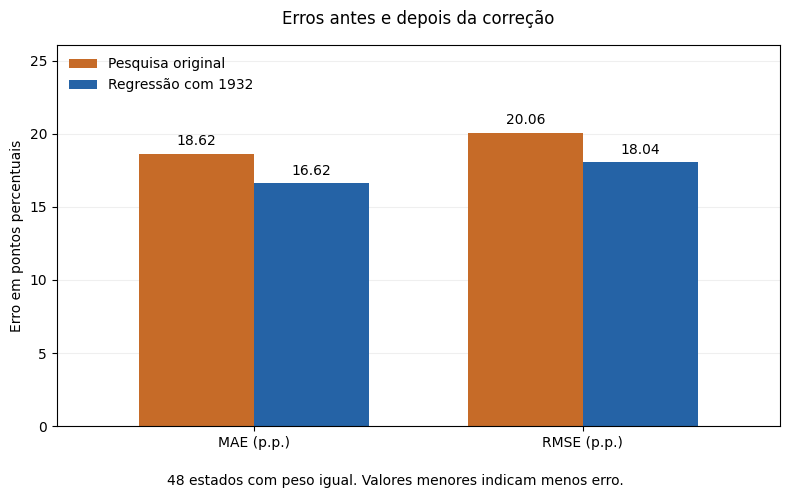

In [21]:
dados_grafico = comparacao_metricas.set_index("Previsão")[
    ["MAE (p.p.)", "RMSE (p.p.)"]
].T

fig, ax = plt.subplots(figsize=(8, 5))

dados_grafico.plot.bar(
    ax=ax,
    color=["#C66B28", "#2563A6"],
    rot=0,
    width=0.7,
)

for barras in ax.containers:
    ax.bar_label(barras, fmt="%.2f", padding=4)

ax.set_title("Erros antes e depois da correção", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Erro em pontos percentuais")
ax.set_ylim(0, dados_grafico.to_numpy().max() * 1.3)
ax.legend(title="", frameon=False, loc="upper left")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)

fig.text(
    0.5, 0.02,
    "48 estados com peso igual. Valores menores indicam menos erro.",
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=(0, 0.06, 1, 1))

fig.savefig(
    PASTA_FIGURAS / "fase2_comparacao_erros.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

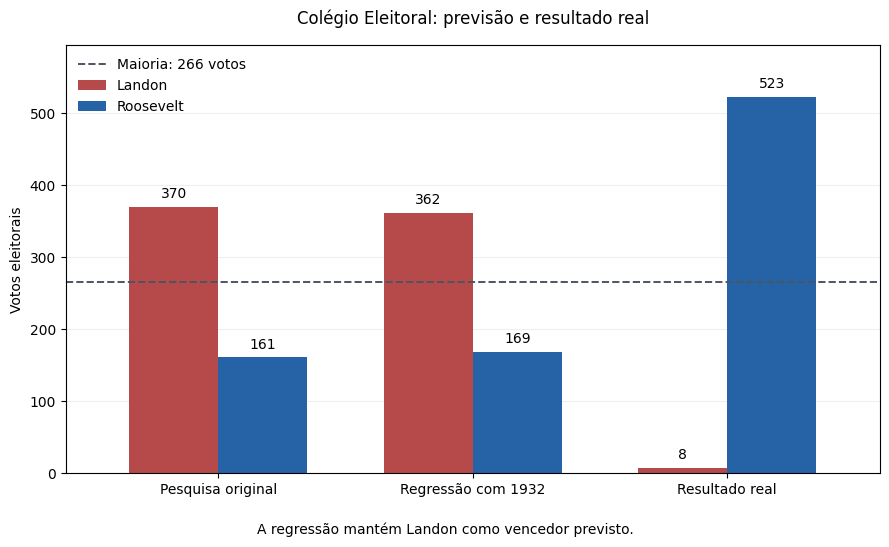

In [22]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colegio_eleitoral.T.plot.bar(
    ax=ax,
    color=["#B64A4A", "#2563A6"],
    rot=0,
    width=0.7,
)

for barras in ax.containers:
    ax.bar_label(barras, fmt="%.0f", padding=4)

maioria = total_eleitoral // 2 + 1

ax.axhline(
    maioria,
    color="#4B5563",
    linestyle="--",
    linewidth=1.4,
    label=f"Maioria: {maioria} votos",
)

ax.set_title("Colégio Eleitoral: previsão e resultado real", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Votos eleitorais")
ax.set_ylim(0, total_eleitoral * 1.12)
ax.legend(title="", frameon=False, loc="upper left")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)

fig.text(
    0.5, 0.02,
    "A regressão mantém Landon como vencedor previsto.",
    ha="center",
    fontsize=10,
)

fig.tight_layout(rect=(0, 0.06, 1, 1))

fig.savefig(
    PASTA_FIGURAS / "fase2_colegio_eleitoral.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

## 11. Exportação das tabelas

Exportamos a base de treinamento, os resultados estaduais,
as métricas e a comparação do Colégio Eleitoral.

Os valores são preservados com sua precisão original.
O arredondamento é utilizado somente na apresentação.

In [23]:
tabelas = {
    "fase2_base_treino_1932.csv": base_treino_1932,
    "fase2_resultados_estados.csv": resultados_estados,
    "fase2_metricas.csv": comparacao_metricas,
    "fase2_colegio_eleitoral.csv": colegio_eleitoral.reset_index(),
}

for nome, tabela in tabelas.items():
    tabela.to_csv(
        PASTA_DADOS / nome,
        index=False,
        encoding="utf-8-sig",
    )

print("As quatro tabelas foram exportadas.")

As quatro tabelas foram exportadas.


## 12. Conclusão e limitações

Usamos uma regressão linear treinada com a pesquisa e os resultados
reais de 1932 para corrigir a pesquisa de 1936.

O MAE caiu de 18,62 para 16,62 pontos percentuais. Isso representa
uma redução de aproximadamente 2,00 pontos percentuais, ou 10,76%
em relação ao erro original. O RMSE caiu de 20,06 para 18,04 pontos
percentuais, uma redução relativa de 10,03%.

O erro absoluto diminuiu nos 48 estados. A quantidade de vencedores
estaduais previstos corretamente passou de 18 para 20, com mudanças
em Nevada e Oregon.

Mesmo com essa melhora, o modelo continuou prevendo a vitória de
Landon, com 362 votos eleitorais, contra 169 de Roosevelt. Na eleição
real, Roosevelt recebeu 523 votos eleitorais e Landon recebeu 8.
Portanto, a correção reduziu os erros, mas não foi suficiente para
acertar o vencedor nacional.

A análise usa dados agregados por estado e apenas uma eleição no
treinamento. Além disso, depende da hipótese de que a relação entre
pesquisa e resultado real observada em 1932 também se aplique a 1936.
Em nove estados, as proporções da pesquisa de 1936 ficaram acima
da maior proporção usada no treinamento, exigindo extrapolação.
Essas limitações precisam ser consideradas ao interpretar os resultados.

In [25]:
from zipfile import ZipFile

arquivos_exportados = (
    sorted(PASTA_DADOS.glob("fase2_*.csv"))
    + sorted(PASTA_FIGURAS.glob("fase2_*.png"))
)

with ZipFile("fase2_resultados.zip", "w") as pacote:
    for arquivo in arquivos_exportados:
        pacote.write(arquivo, arcname=arquivo.as_posix())

print(f"Pacote criado com {len(arquivos_exportados)} arquivos.")

files.download("fase2_resultados.zip")

Pacote criado com 6 arquivos.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Referências

ALENCAR, Airlane P. **Não resposta**. São Paulo: Instituto de Matemática e Estatística, Universidade de São Paulo, 2023. Material de aula. Disponível em: material da USP - https://www.ime.usp.br/~lane/home/MAE0315/Nonresponse.pdf Acesso em: 17 set. 2026.



